# Notebook 1 — Binary multiplication and Booth recoding

This notebook walks from naive binary shift-add multiplication to **radix-4 Booth recoding**, and shows quantitatively how Booth reduces the number of partial-product rows produced by a multiplier.

**Prerequisites:** none — this is the entry notebook of the series.  
**Reading time:** about 25 minutes.

The series-wide thesis is that for **36-bit RNS** (residue number system) modular multiplication on commodity CPU/GPU hardware, choosing 30/31-bit primes that fit native arithmetic widths usually beats trying to optimize 36-bit multiplication via Booth-style recoding. This notebook builds the prerequisite intuition: *what Booth actually does*.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from ipywidgets import Dropdown, IntSlider, interact

from rns_arithmetic import bits, booth, visualization

visualization.apply_style()

## 1.1 Ordinary shift-add multiplication

**Takeaway:** integer multiplication can be viewed as a sum of shifted copies of one operand, with one shifted copy per `1` bit in the other.

For two integers $A$ and $B$ with $B = \sum_i b_i\, 2^i$:

$$
A \cdot B \;=\; \sum_{i \,:\, b_i = 1} (A \ll i)
$$

For $A = 13$, $B = 60 = \texttt{0b00111100}$:

$$
13 \cdot 60 \;=\; 13 \cdot 2^2 + 13 \cdot 2^3 + 13 \cdot 2^4 + 13 \cdot 2^5 \;=\; 780.
$$

Notice that $\texttt{0b00111100} = 2^6 - 2^2$. The same product can be written as a single shifted **add** plus a single shifted **subtract**:

$$
13 \cdot 60 \;=\; (13 \ll 6) - (13 \ll 2).
$$

This is the seed of Booth's idea — but to be precise: this is not literally "one CPU add and one CPU subtract" in a high-level program. It means that *inside a multiplier circuit*, two signed partial-product rows replace four positive rows.

In [2]:
A, B = 13, 60
naive_partial_rows = [(i, A << i) for i in range(B.bit_length()) if (B >> i) & 1]
df_rows = pd.DataFrame(naive_partial_rows, columns=["bit position i", "A << i"])
df_rows.loc["sum"] = ["", df_rows["A << i"].sum()]
df_rows

,bit position i,A << i
0,2,52
1,3,104
2,4,208
3,5,416
sum,,780


For a uniformly random multiplier of width $w$ bits, each bit is `1` with probability $\tfrac{1}{2}$, so naive shift-add expects $w/2$ non-zero partial-product rows. For $w = 36$ this is 18.

## 1.2 Radix-2 Booth recoding

**Takeaway:** Booth recoding rewrites $B$ as a sum of *signed* shifted copies, with digits in $\{-1, 0, +1\}$. A run of consecutive `1`s of length $\ell$ becomes one `+1` digit (one position past the run end) and one `-1` digit (at the run start).

Identity for a run of $\ell$ ones starting at bit $p$:

$$
\underbrace{1\ldots 1}_{\ell\,\text{ones}} \cdot 2^p \;=\; 2^{p+\ell} - 2^p.
$$

Scanning bit pairs $(b_i, b_{i-1})$ with implicit $b_{-1} = 0$, the digit at position $i$ is

$$d_i \;=\; b_{i-1} - b_i.$$

Because an unsigned $w$-bit number can have a run that *extends to the MSB*, our `booth_radix2_digits` returns $w + 1$ digits — the extra position closes a run that would otherwise run off the top.

In [3]:
B, width = 60, 8
digits_r2 = booth.booth_radix2_digits(B, width)
reconstruction = sum(d * (1 << i) for i, d in enumerate(digits_r2))
df_r2 = pd.DataFrame(
    {
        "position i": list(range(len(digits_r2))),
        "d_i": digits_r2,
        "d_i * 2**i": [d << i for i, d in enumerate(digits_r2)],
    }
)
print(f"B (binary, MSB first) = {bits.format_binary(B, width)}  (= {B})")
print(f"sum of d_i * 2**i     = {reconstruction}")
df_r2

B (binary, MSB first) = 00111100  (= 60)
sum of d_i * 2**i     = 60


,position i,d_i,d_i * 2**i
0,0,0,0
1,1,0,0
2,2,-1,-4
3,3,0,0
4,4,0,0
5,5,0,0
6,6,1,64
7,7,0,0
8,8,0,0


## 1.3 Radix-4 Booth recoding

**Takeaway:** radix-4 Booth groups *two bits at a time* and produces digits in $\{-2, -1, 0, +1, +2\}$. This roughly halves the number of partial-product rows, at the cost of needing a `×2` partial product (a single shift) in addition to `×1`.

Scanning overlapping 3-bit windows $(b_{2i+1}, b_{2i}, b_{2i-1})$ with $b_{-1} = 0$, the digit at position $i$ is

$$d_i \;=\; b_{2i-1} + b_{2i} - 2\,b_{2i+1}.$$

The standard recoding table:

| 3-bit window | $d_i$ |
| ------------ | ----: |
| `000`        |   0   |
| `001`        |  +1   |
| `010`        |  +1   |
| `011`        |  +2   |
| `100`        |  -2   |
| `101`        |  -1   |
| `110`        |  -1   |
| `111`        |   0   |

Six of the eight 3-bit windows produce a non-zero digit. So for a uniformly random multiplier of width $w$, the **expected number of non-zero partial-product rows** under radix-4 Booth is

$$
0.75 \cdot \left\lceil \tfrac{w}{2} \right\rceil.
$$

For $w = 36$ this is $0.75 \cdot 18 = 13.5$ rows — versus 18 for naive shift-add.

In [4]:
A, B, width = 13, 60, 8
digits_r4 = booth.booth_radix4_digits_unsigned(B, width)
df_r4 = pd.DataFrame(
    {
        "position i": list(range(len(digits_r4))),
        "d_i": digits_r4,
        "d_i * 2**(2i)": [d << (2 * i) for i, d in enumerate(digits_r4)],
    }
)
prod = booth.booth_mul(A, B, width)
print(f"B (binary, MSB first) = {bits.format_binary(B, width)}  (= {B})")
print(f"booth_mul(13, 60, 8)  = {prod}   (A * B = {A * B}, match = {prod == A * B})")
df_r4

B (binary, MSB first) = 00111100  (= 60)
booth_mul(13, 60, 8)  = 780   (A * B = 780, match = True)


,position i,d_i,d_i * 2**(2i)
0,0,0,0
1,1,-1,-4
2,2,0,0
3,3,1,64
4,4,0,0


## 1.4 Cost comparison

The table below collects the structural row count for several common bit widths. The library functions `booth.naive_shift_add_cost` and `booth.booth_radix4_cost` produce these numbers, and the figure that follows visualizes the same data.

In [5]:
sweep_widths = [4, 8, 16, 32, 36, 64]
df_cost = pd.DataFrame(visualization.expected_nonzero_for_widths(sweep_widths)).rename(
    columns={
        "bit_width": "bit width (w)",
        "naive_expected_rows": "naive E[non-zero rows]",
        "booth_r4_expected_rows": "radix-4 Booth E[non-zero rows]",
        "booth_r4_groups": "radix-4 Booth groups (ceil(w/2))",
    }
)
df_cost

,bit width (w),naive E[non-zero rows],radix-4 Booth E[non-zero rows],radix-4 Booth groups (ceil(w/2))
0,4.0,2.0,1.5,2.0
1,8.0,4.0,3.0,4.0
2,16.0,8.0,6.0,8.0
3,32.0,16.0,12.0,16.0
4,36.0,18.0,13.5,18.0
5,64.0,32.0,24.0,32.0


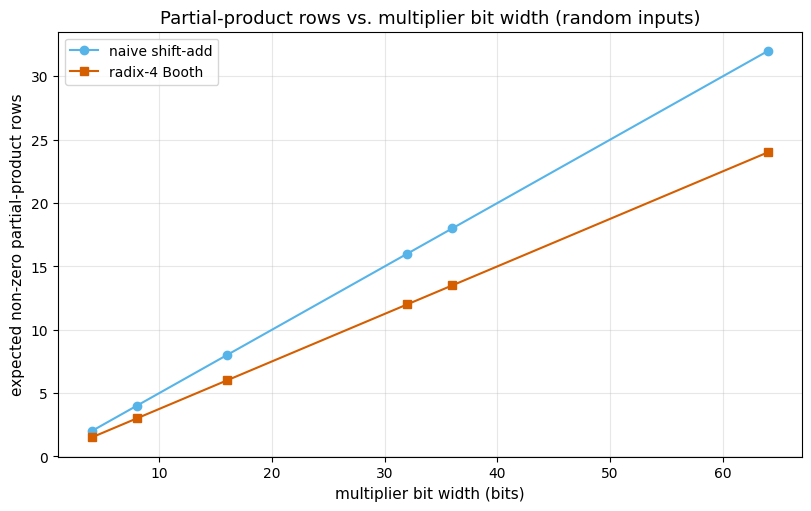

In [6]:
fig = visualization.plot_partial_rows_vs_width(sweep_widths)
plt.show()

### Interactive: explore Booth recoding

Drag the sliders to see how the recoding changes for different `(A, B, bit width, radix)`. The static cell below shows the default state so this notebook is meaningful when rendered on GitHub without a kernel; the live widget appears beneath it when run interactively.

In [7]:
def show_recoding(A: int, B: int, width: int, radix: str) -> None:
    print(f"A = {A}  ({bits.format_binary(A, width)})")
    print(f"B = {B}  ({bits.format_binary(B, width)})")
    if radix == "naive":
        rows = [(i, A << i) for i in range(width) if (B >> i) & 1]
        print(f"naive non-zero rows = {len(rows)}")
        for i, v in rows:
            print(f"  +A << {i:2d}  =  {v}")
        prod = sum(v for _, v in rows)
    elif radix == "booth_r2":
        d = booth.booth_radix2_digits(B, width)
        nonzero = [(i, dv) for i, dv in enumerate(d) if dv != 0]
        print(f"radix-2 Booth non-zero rows = {len(nonzero)}")
        for i, dv in nonzero:
            print(f"  {dv:+d} * A << {i:2d}  =  {dv * (A << i)}")
        prod = sum(dv * (A << i) for i, dv in enumerate(d))
    else:  # booth_r4
        d = booth.booth_radix4_digits_unsigned(B, width)
        nonzero = [(i, dv) for i, dv in enumerate(d) if dv != 0]
        print(f"radix-4 Booth non-zero rows = {len(nonzero)}")
        for i, dv in nonzero:
            print(f"  {dv:+d} * A << {2 * i:2d}  =  {dv * (A << (2 * i))}")
        prod = booth.booth_mul(A, B, width)
    print()
    print(f"reconstructed = {prod}")
    print(f"A * B         = {A * B}")
    print(f"match         = {prod == A * B}")


show_recoding(A=13, B=60, width=8, radix="booth_r4")

A = 13  (00001101)
B = 60  (00111100)
radix-4 Booth non-zero rows = 2
  -1 * A <<  2  =  -52
  +1 * A <<  6  =  832

reconstructed = 780
A * B         = 780
match         = True


In [8]:
interact(
    show_recoding,
    A=IntSlider(value=13, min=0, max=255, description="A"),
    B=IntSlider(value=60, min=0, max=255, description="B"),
    width=IntSlider(value=8, min=4, max=16, step=4, description="bit width"),
    radix=Dropdown(
        options=["naive", "booth_r2", "booth_r4"], value="booth_r4", description="radix"
    ),
);

interactive(children=(IntSlider(value=13, description='A', max=255), IntSlider(value=60, description='B', max=…

## 1.5 How much does Booth save? Random-input expectation

The plot above already showed the gap — to put numbers on it: at $w = 36$, Booth replaces about 18 expected non-zero rows (naive) with about 13.5 (radix-4 Booth). That is a real reduction, but as Notebook 2 shows, **it is not large enough to overcome the software-level overhead of multiword carry propagation** when one tries to *implement* a Booth-style 36-bit multiply on top of native 32-bit machine words.

The right comparison for software is therefore not "naive shift-add vs. Booth shift-add" but rather "choose RNS primes whose products fit native widths". Notebook 3 makes that argument quantitative.

## Takeaway

- **Booth recoding is a partial-product reduction technique** for hardware multipliers. Radix-2 produces digits in $\{-1, 0, +1\}$; radix-4 produces digits in $\{-2, -1, 0, +1, +2\}$ and roughly halves the number of partial-product rows.
- For a uniformly random $w$-bit multiplier, expected non-zero rows are $w/2$ (naive) versus $0.75 \cdot \lceil w/2 \rceil$ (radix-4 Booth). At $w = 36$: about 18 vs 13.5.
- For unsigned operands, the recoding needs **one extra closure digit** at the top (in $\{0, +1\}$) to capture a run of `1`s extending to the MSB. The library exposes this directly: `booth_radix4_digits_unsigned(b, w)` returns $\lceil (w+1)/2 \rceil$ digits.
- *As a software method on commodity INT32/INT8 units, Booth becomes a sequence of shifted multiword add/sub operations.* The next notebook explains why that matters for 36-bit RNS modular multiplication.